<a href="https://colab.research.google.com/github/francielekreff/crop-recomendation/blob/main/crop_recomendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Crop Recommendation Based on Soil Data

Understanding soil characteristics is important for sustainable agriculture and optimizing crop production.

The crop recommendation based on soil analysis helps farmers to:

*   **Optimize Yields**: Plant crops that naturally thrive in the existing soil environment, leading to better growth and higher productivity.

*   **Efficient Resource Use**: Avoid wasting resources (water, fertilizers) on crops that are ill-suited for the soil.

*   **Prevent Nutrient Imbalances**: Match crop needs with soil nutrient availability, promoting healthy plant development and preventing deficiencies or toxicities.

*   **Sustainable Farming**: Reduce environmental impact by making informed decisions that minimize the need for excessive interventions.

### Crop Recomendation Dataset

Dataset link on Kaggle:
[https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset](https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset)

The dataset contains information related to crop recommendation. It includes environmental parameters and the recommended crop.

The columns are:

*   `N`: Nitrogen content in the soil
*   `P`: Phosphorus content in the soil
*   `K`: Potassium content in the soil
*   `temperature`: Temperature in Celsius
*   `humidity`: Relative humidity in %
*   `ph`: pH value of the soil
*   `rainfall`: Rainfall in mm
*   `label`: The recommended crop (target variable)

### **Imports**

In [ ]:
# Data Handling and OS Operations
import kagglehub
import pandas as pd
import os

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical Operations
import numpy as np

# Dimensionality Reduction
from sklearn.decomposition import PCA
import umap

# Model Selection and Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Model Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


### **Dataset Load**


In [ ]:
# Download dataset using kagglehub
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'Crop_recommendation.csv')

# Load the dataset into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first rows of the DataFrame
display(df.head())


Using Colab cache for faster access to the 'crop-recommendation-dataset' dataset.


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


### **EDA (Exploratory Data Analysis)**

In [ ]:
# Print the number of instances and attributes in DataFrame
print(f"Number of instances: {df.shape[0]}")
print(f"Total number of attributes (including target): {df.shape[1]}")
print()

# Separate numerical and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Print the number of numerical and categorical attributes
print(f"Number of numerical attributes: {len(numeric_cols)}")
print(f"Number of categorical attributes: {len(categorical_cols)}")
print()


Number of instances: 2200
Total number of attributes (including target): 8

Number of numerical attributes: 7
Number of categorical attributes: 1



#### Distribution of the target variable, `label`:



Number of unique classes:
22

Distribution of Crop Labels:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64



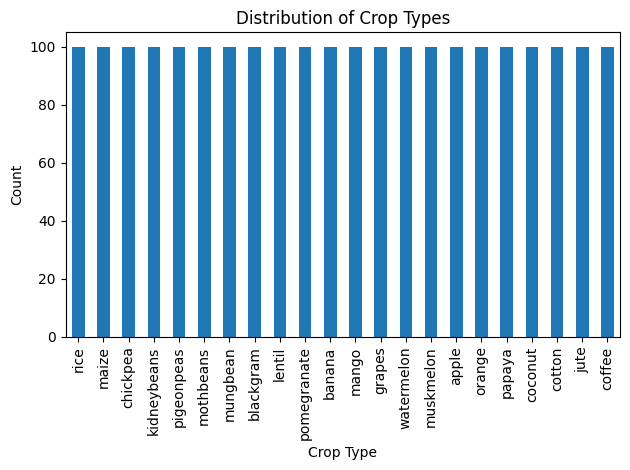

In [ ]:
# Print the number of unique classes in label
print("Number of unique classes:")
print(df['label'].nunique())
print()

# Get and print the count of each unique label
print("Distribution of Crop Labels:")
print(df['label'].value_counts())
print()

# Visualize the distribution of the target variable
plt.figure()
df['label'].value_counts().plot(kind='bar')
plt.title('Distribution of Crop Types')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


#### Distribution of Numerical Features:

Missing values in each column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


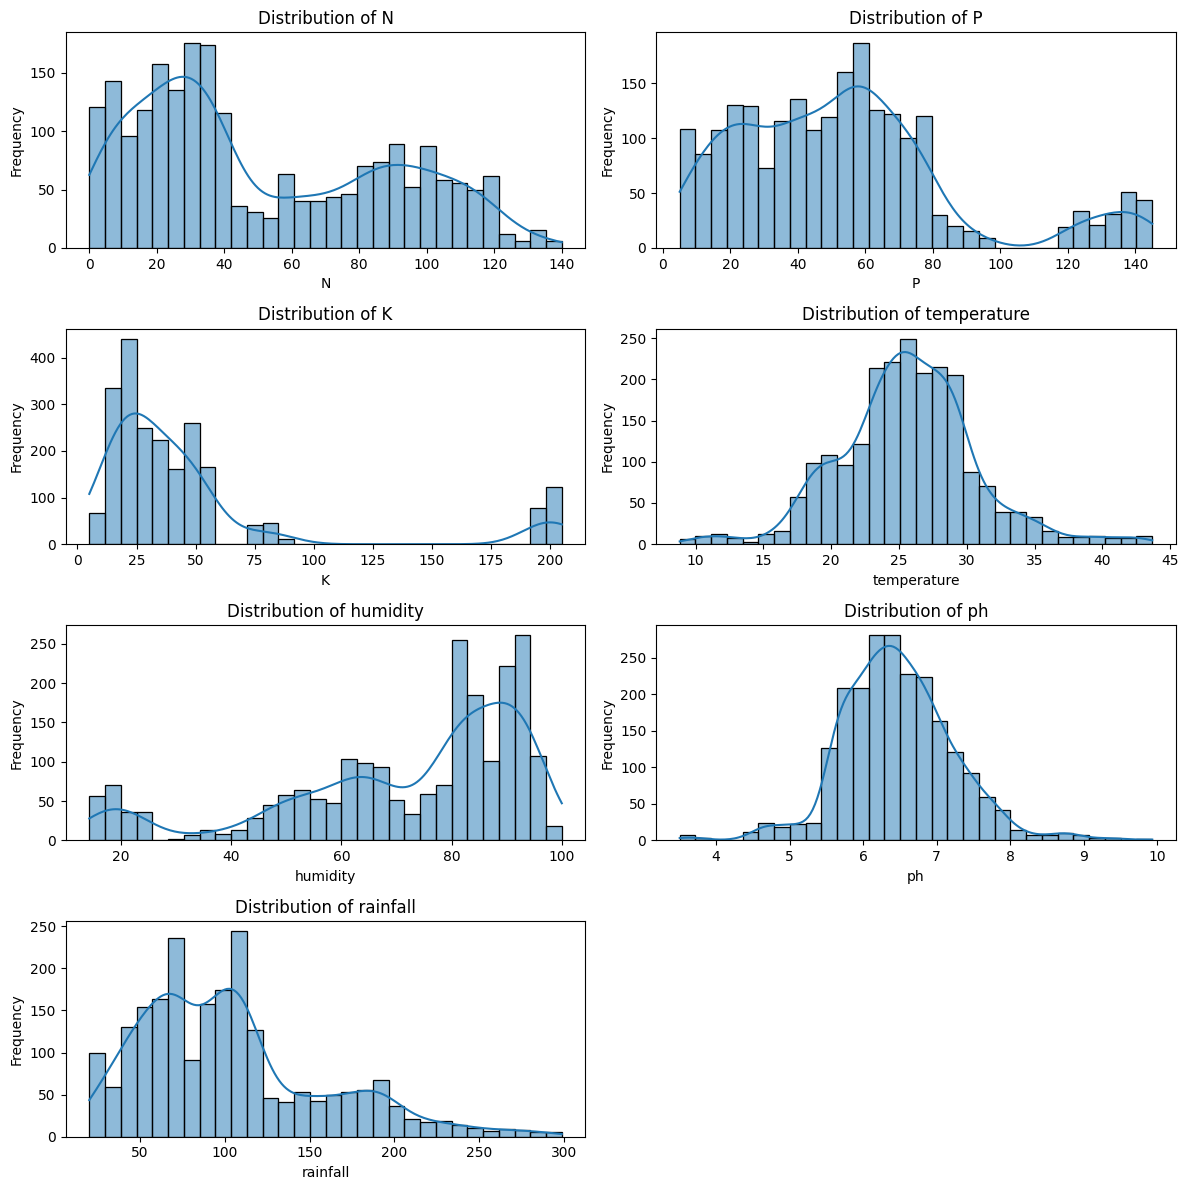

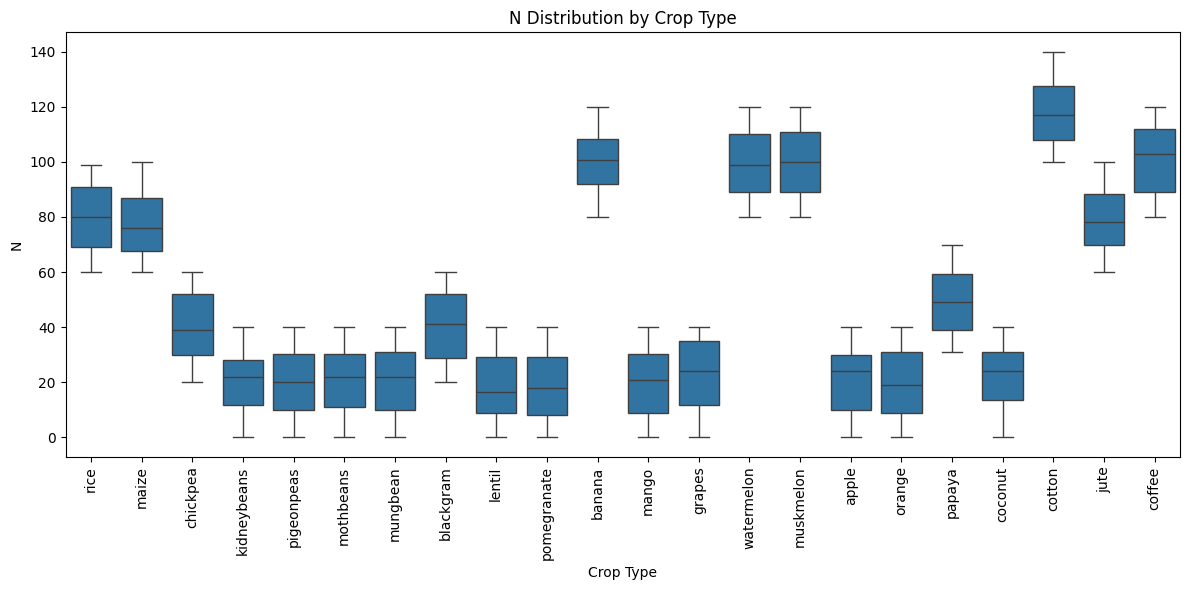

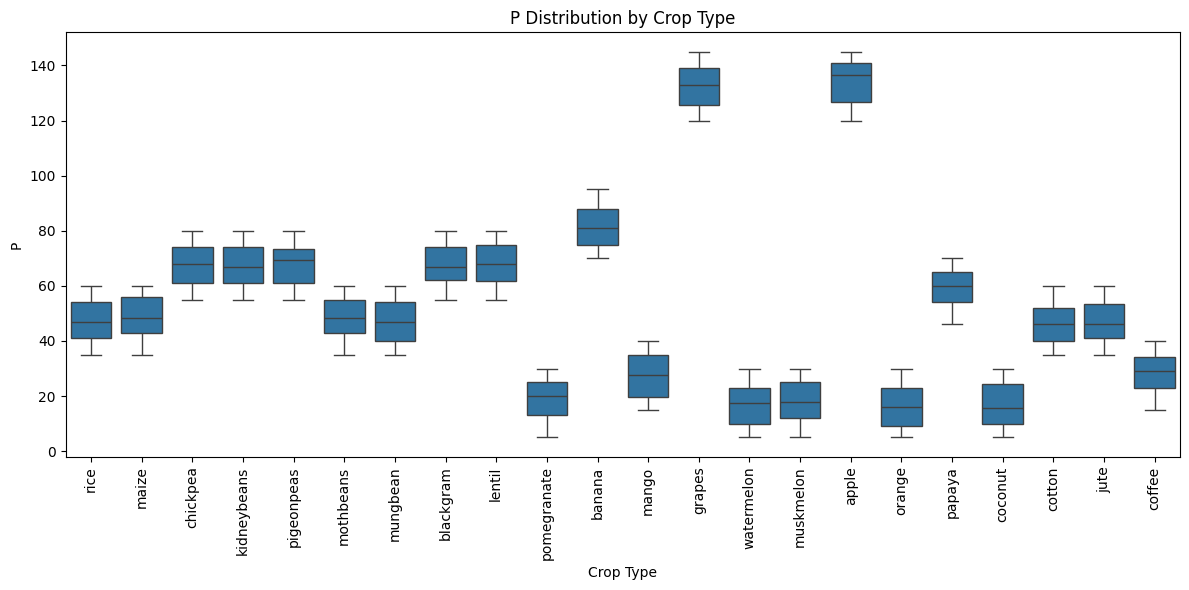

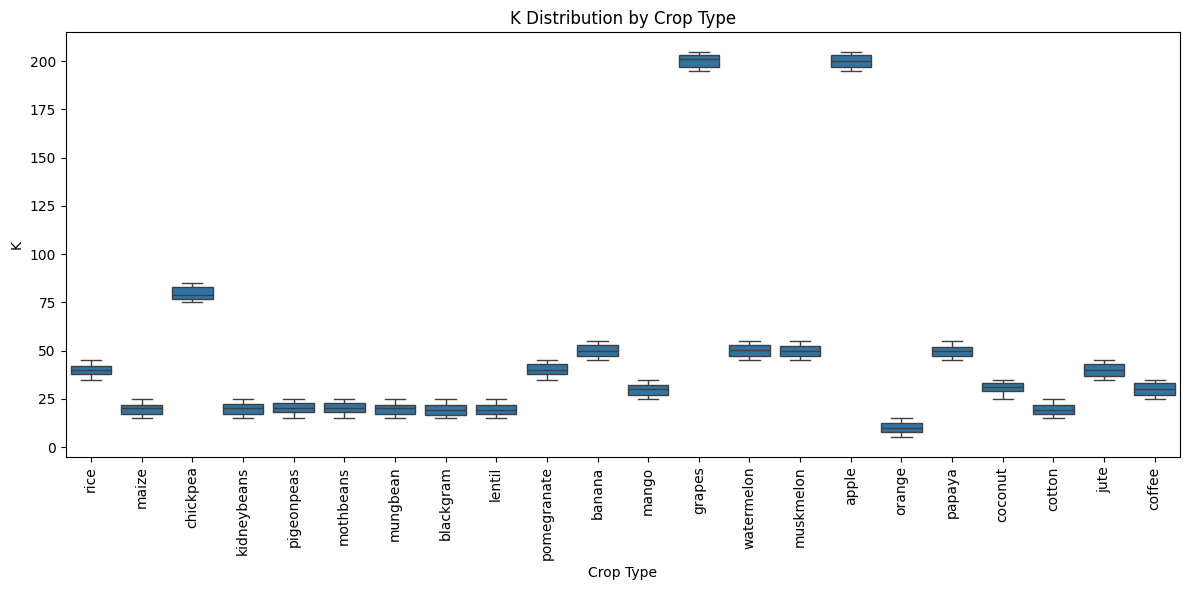

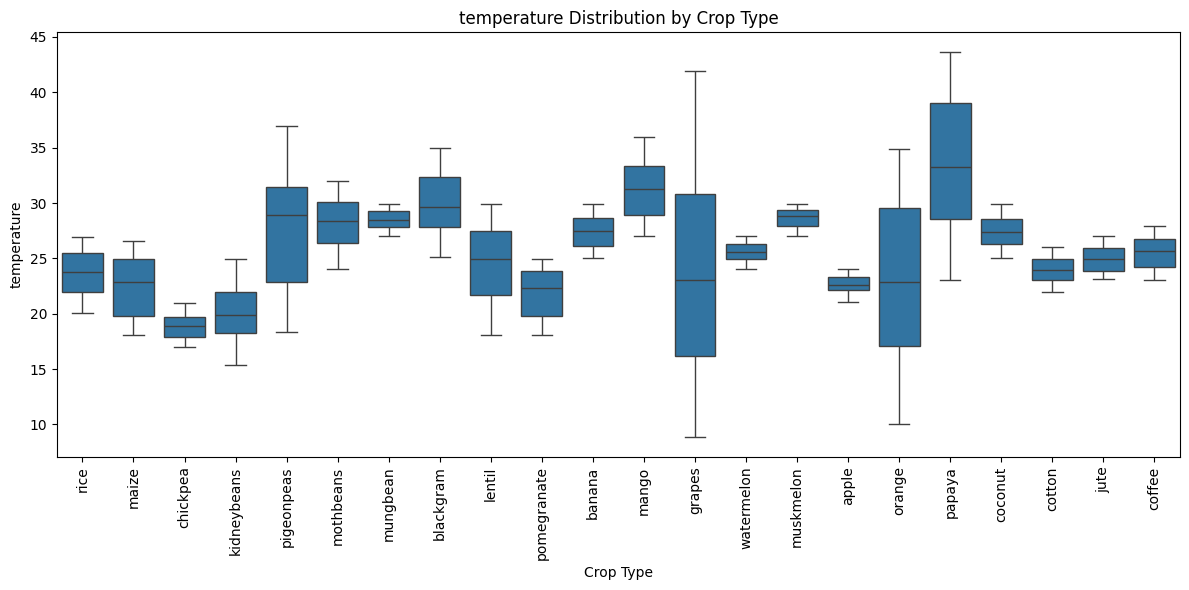

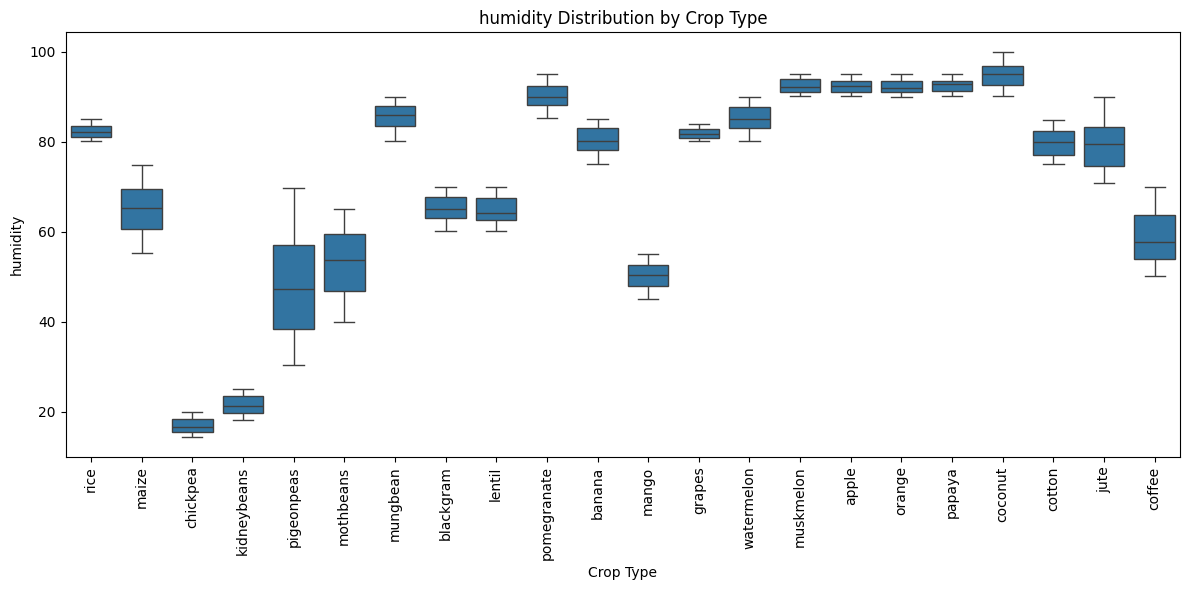

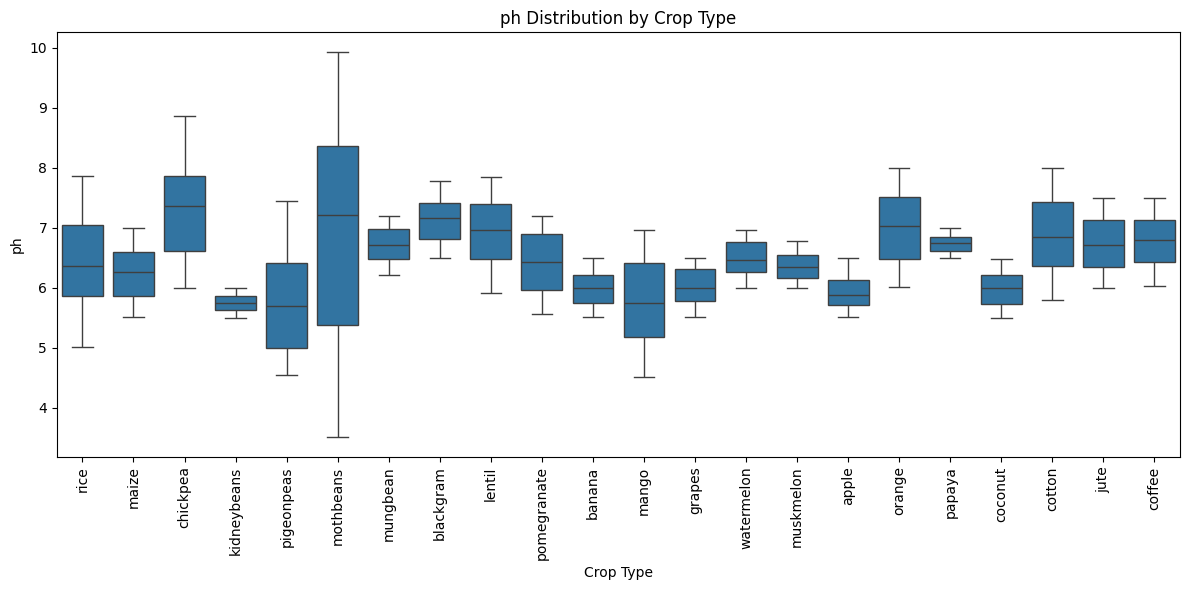

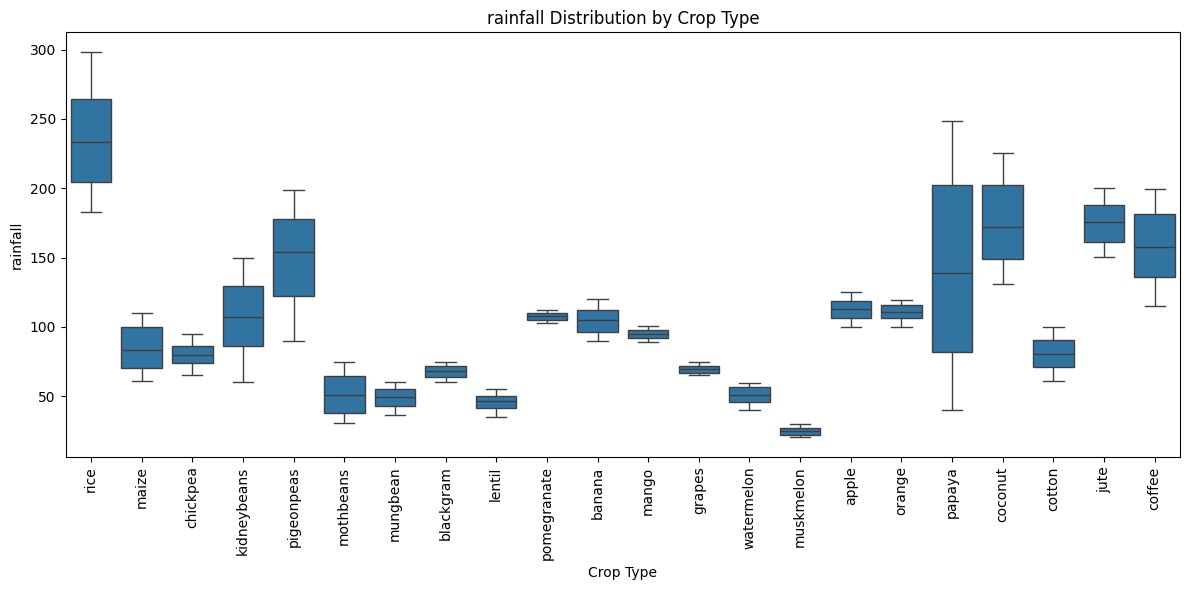

In [ ]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())
print()

# Display descriptive statistics for numerical columns
print("Descriptive statistics:")
display(df.describe().T)
print()

# Histograms for feature distributions
numerical_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

plt.figure(figsize=(12, 12))
for i, feature in enumerate(numerical_features):
    plt.subplot(4, 2, i + 1)
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Boxplots by class for feature distributions
for feature in numerical_features:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='label', y=feature, data=df)
    plt.title(f'{feature} Distribution by Crop Type')
    plt.xlabel('Crop Type')
    plt.ylabel(feature)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


#### Pearson Correlation Heatmap:

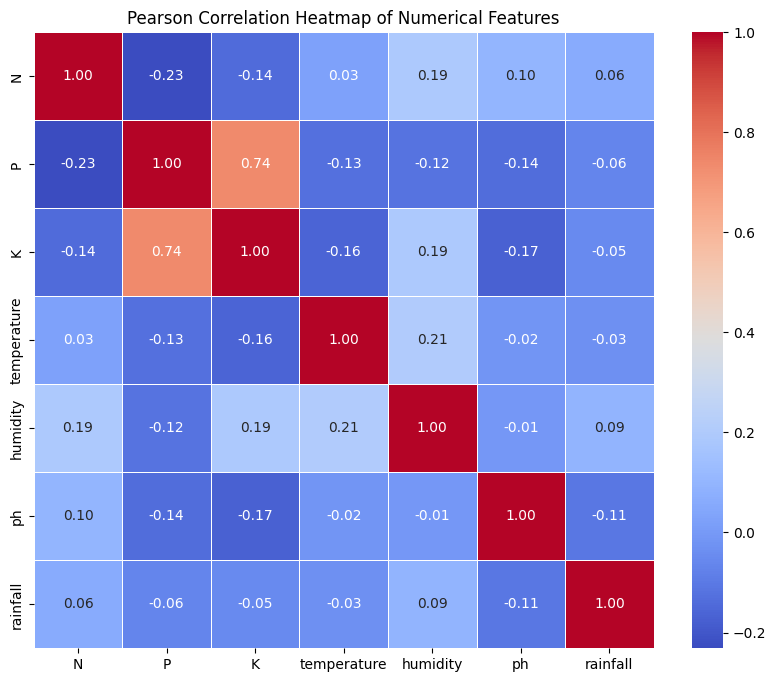

In [ ]:
# Calculate the Pearson correlation matrix for numerical features
correlation_matrix = df[numerical_features].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Heatmap of Numerical Features')
plt.show()


#### PCA (Principal Component Analysis):

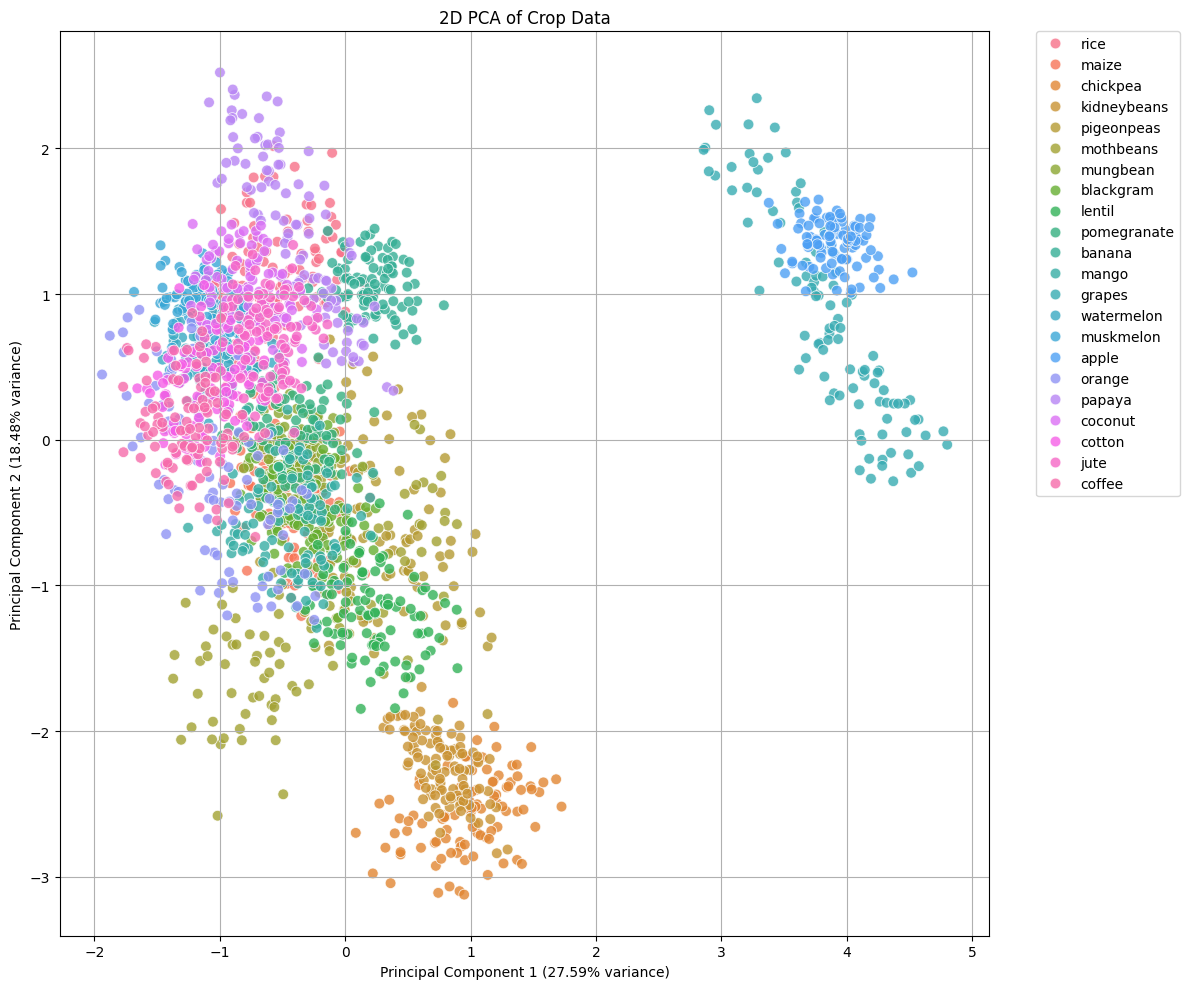

Total variance explained by 2 components: 46.07%


In [ ]:
# Separate features (X) and target (y) again for clarity in this step
X = df[numerical_features]
y = df['label']

# Standardize the features before applying PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['label'] = y.reset_index(drop=True)

# Plot the PCA components
plt.figure(figsize=(12, 10))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='label', data=pca_df, s=60, alpha=0.8)
plt.title('2D PCA of Crop Data')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 components: {(pca.explained_variance_ratio_.sum()*100):.2f}%")


#### UMAP (Uniform Manifold Approximation and Projection):



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


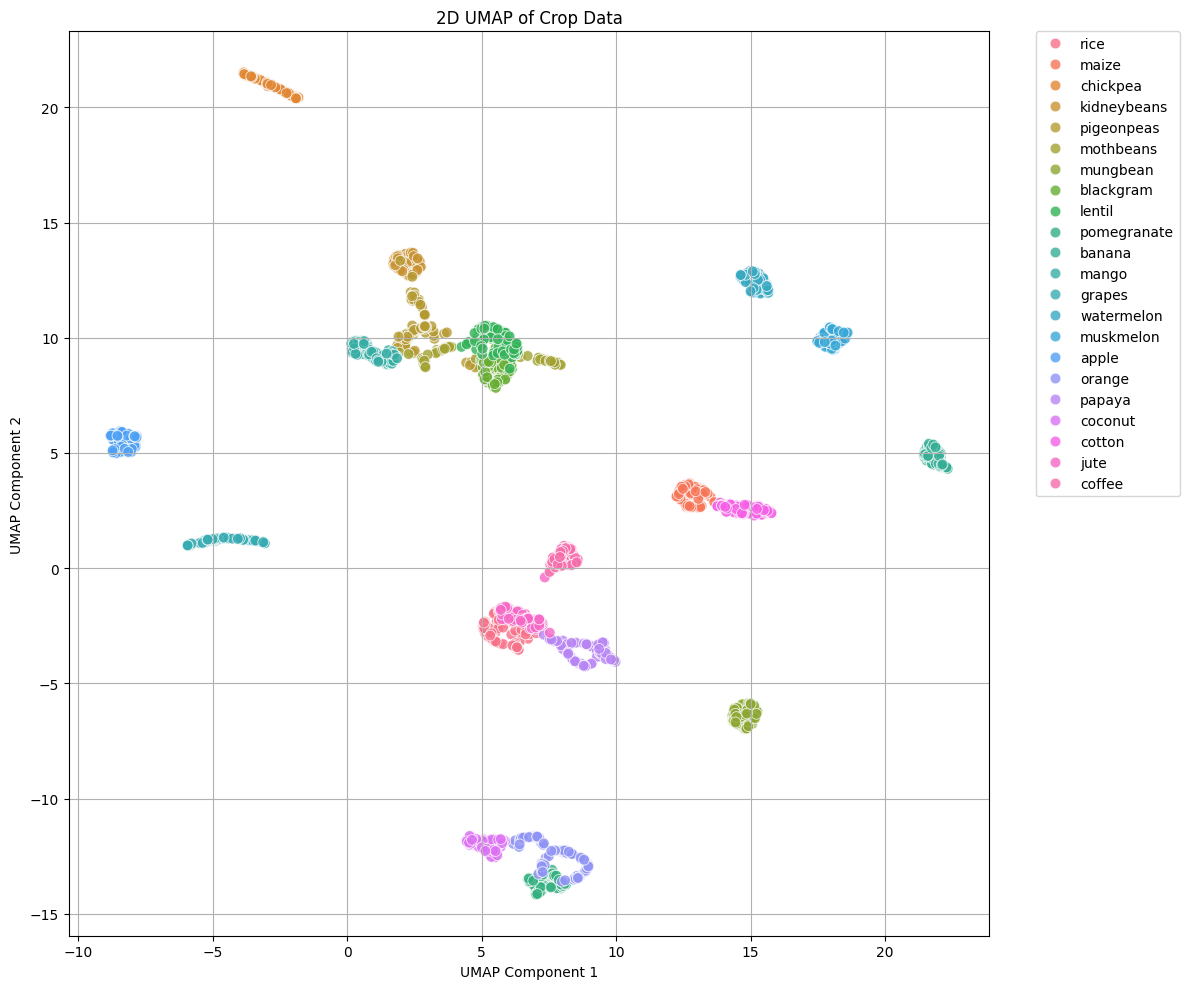

In [ ]:
# Assuming X_scaled and y are already defined from the PCA section
# X is the feature data, y is the target labels

# Initialize and apply UMAP
reducer = umap.UMAP(random_state=42) # Set a random state for reproducibility
X_umap = reducer.fit_transform(X_scaled)

# Create a DataFrame for plotting
umap_df = pd.DataFrame(data=X_umap, columns=['UMAP Component 1', 'UMAP Component 2'])
umap_df['label'] = y.reset_index(drop=True)

# Plot the UMAP components
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='UMAP Component 1',
    y='UMAP Component 2',
    hue='label',
    data=umap_df,
    s=60,
    alpha=0.8
)
plt.title('2D UMAP of Crop Data')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()

### **Train/Test Holdout**

In [ ]:
# Separate features (X) and target (y)
X = df.drop('label', axis=1)
y = df['label']

# Perform stratified holdout split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (1760, 7)
Shape of X_test: (440, 7)
Shape of y_train: (1760,)
Shape of y_test: (440,)



### **Spot Checking**

In [ ]:
# Define the cross-validation strategy
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create a pipeline for KNN
k_neighbors_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Create a pipeline for Naive Bayes
naive_bayes_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

# Create a pipeline for Support Vector Machine (SVM)
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

# Create a pipeline for Random Forest
random_forest_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# Create a pipeline for Gradient Boosting
gradient_boosting_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', GradientBoostingClassifier(random_state=42))
])

# Perform cross-validation for KNN using the pipeline
k_neighbors_scores = cross_val_score(k_neighbors_pipeline, X_train, y_train, cv=kf, scoring='f1_weighted')
print(f"KNN Cross-Validation F1-score: {np.mean(k_neighbors_scores):.4f} (+/- {np.std(k_neighbors_scores):.4f})")

# Perform cross-validation for Naive Bayes using the pipeline
naive_bayes_scores = cross_val_score(naive_bayes_pipeline, X_train, y_train, cv=kf, scoring='f1_weighted')
print(f"Naive Bayes Cross-Validation F1-score: {np.mean(naive_bayes_scores):.4f} (+/- {np.std(naive_bayes_scores):.4f})")

# Perform cross-validation for SVM using the pipeline
svm_scores = cross_val_score(svm_pipeline, X_train, y_train, cv=kf, scoring='f1_weighted')
print(f"SVM Cross-Validation F1-score: {np.mean(svm_scores):.4f} (+/- {np.std(svm_scores):.4f})")

# Perform cross-validation for Random Forest using the pipeline
random_forest_scores = cross_val_score(random_forest_pipeline, X_train, y_train, cv=kf, scoring='f1_weighted')
print(f"Random Forest Cross-Validation F1-score: {np.mean(random_forest_scores):.4f} (+/- {np.std(random_forest_scores):.4f})")

# Perform cross-validation for Gradient Boosting using the pipeline
gradient_boosting_scores = cross_val_score(gradient_boosting_pipeline, X_train, y_train, cv=kf, scoring='f1_weighted')
print(f"Gradient Boosting Cross-Validation F1-score: {np.mean(gradient_boosting_scores):.4f} (+/- {np.std(gradient_boosting_scores):.4f})")


KNN Cross-Validation F1-score: 0.9650 (+/- 0.0124)
Naive Bayes Cross-Validation F1-score: 0.9949 (+/- 0.0042)
SVM Cross-Validation F1-score: 0.9788 (+/- 0.0106)
Random Forest Cross-Validation F1-score: 0.9926 (+/- 0.0059)
Gradient Boosting Cross-Validation F1-score: 0.9869 (+/- 0.0036)


### **Nested Cross-Validation**

In [ ]:
# Define the outer cross-validation strategy (same as kf) for consistent splitting
outer_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Naive Bayes (GaussianNB) Nested Cross-Validation
print("Starting Nested CV for Naive Bayes...")

# Define the search space for Naive Bayes
param_grid_nb = {
  'nb__var_smoothing': np.logspace(-9, -3, num=20)
}

# Inner loop: GridSearchCV for hyperparameter tuning
inner_grid_nb = GridSearchCV(naive_bayes_pipeline, param_grid_nb, cv=kf, scoring='f1_weighted', n_jobs=-1)

# Outer loop: Evaluate the best model from GridSearchCV
nested_scores_nb = cross_val_score(inner_grid_nb, X_train, y_train, cv=outer_kf, scoring='f1_weighted', n_jobs=-1)

print(f"Naive Bayes Nested CV F1-score: {np.mean(nested_scores_nb):.4f} (+/- {np.std(nested_scores_nb):.4f})")
print()

# Random Forest Nested Cross-Validation
print("Starting Nested CV for Random Forest...")

# Define the search space for Random Forest
param_grid_rf = {
    'rf__n_estimators': [50, 100, 200], # Number of trees in the forest
    'rf__max_depth': [None, 10, 20],    # Maximum tree depth
    'rf__min_samples_leaf': [1, 2, 4]   # Minimum number of samples required to be at a leaf node
}

# Inner loop: GridSearchCV for hyperparameter tuning
inner_grid_rf = GridSearchCV(random_forest_pipeline, param_grid_rf, cv=kf, scoring='f1_weighted', n_jobs=-1)

# Outer loop: Evaluate the best model from GridSearchCV
nested_scores_rf = cross_val_score(inner_grid_rf, X_train, y_train, cv=outer_kf, scoring='f1_weighted', n_jobs=-1)

print(f"Random Forest Nested CV F1-score: {np.mean(nested_scores_rf):.4f} (+/- {np.std(nested_scores_rf):.4f})")
print()

# Gradient Boosting Nested Cross-Validation
print("Starting Nested CV for Gradient Boosting...")

# Define the search space for Gradient Boosting
param_grid_gb = {
    'gb__n_estimators': [50, 100, 200],    # Number of boosting stages
    'gb__learning_rate': [0.05, 0.1, 0.2], # Learning rate
    'gb__max_depth': [3, 5, 7]             # Maximum depth of individual estimators
}

# Inner loop: GridSearchCV for hyperparameter tuning
inner_grid_gb = GridSearchCV(gradient_boosting_pipeline, param_grid_gb, cv=kf, scoring='f1_weighted', n_jobs=-1)

# Outer loop: Evaluate the best model from GridSearchCV
nested_scores_gb = cross_val_score(inner_grid_gb, X_train, y_train, cv=outer_kf, scoring='f1_weighted', n_jobs=-1)

print(f"Gradient Boosting Nested CV F1-score: {np.mean(nested_scores_gb):.4f} (+/- {np.std(nested_scores_gb):.4f})")
print()


Starting Nested CV for Naive Bayes...
Naive Bayes Nested CV F1-score: 0.9949 (+/- 0.0042)

Starting Nested CV for Random Forest...
Random Forest Nested CV F1-score: 0.9920 (+/- 0.0071)

Starting Nested CV for Gradient Boosting...
Gradient Boosting Nested CV F1-score: 0.9868 (+/- 0.0036)



### **Grid Search Cross-Validation**

In [ ]:
# Create the GridSearchCV object
grid_search_nb = GridSearchCV(naive_bayes_pipeline, param_grid_nb, cv=kf, scoring='f1_weighted', n_jobs=-1, verbose=1)

# Execute the grid search on the training data
grid_search_nb.fit(X_train, y_train)

print(f"Best parameters for Naive Bayes: {grid_search_nb.best_params_}")
print(f"Best F1-score for Naive Bayes: {grid_search_nb.best_score_:.4f}")


Starting hyperparameter tuning for Naive Bayes...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for Naive Bayes: {'nb__var_smoothing': np.float64(1e-09)}
Best F1-score for Naive Bayes: 0.9949



### **Final Model**

Accuracy: 0.9955
Precision: 0.9959
Recall 0.9955
F1-Score: 0.9954

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00  

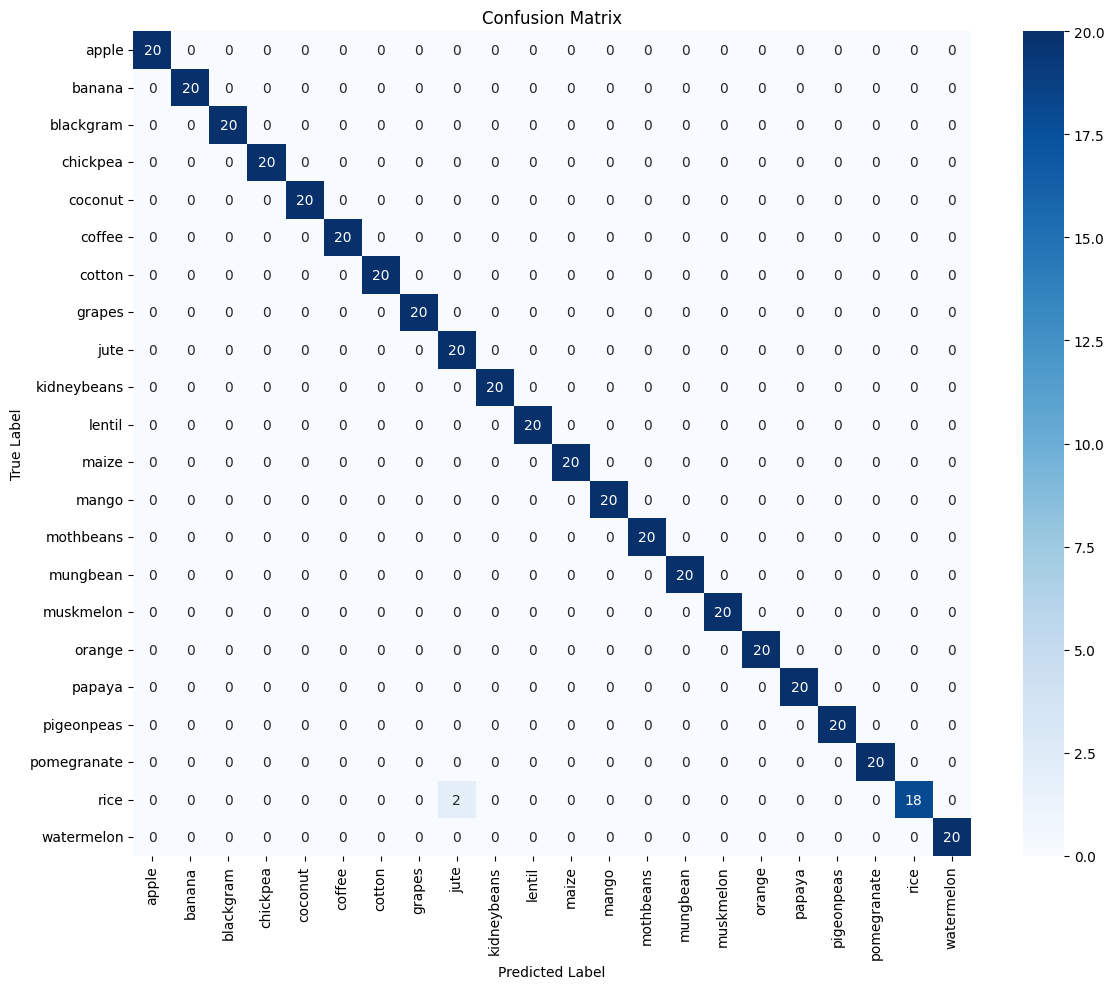

In [ ]:
# Get the best estimator from GridSearchCV
best_naive_bayes_model = grid_search_nb.best_estimator_

# Train the best model on the entire training dataset
best_naive_bayes_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_naive_bayes_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=best_naive_bayes_model.classes_, yticklabels=best_naive_bayes_model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
